# Apex Predictor — Analisi del modello

Analisi delle feature e del comportamento del modello: importanza reale, ridondanza tra feature correlate, e verifica di overfitting confrontando performance su train vs test

In [39]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.inspection import permutation_importance

from src.data_loading import load_raw_data, build_working_dataset
from src.features import build_all_features
from src.train import temporal_split, train_champion_model, FEATURE_COL

data = load_raw_data()
df = build_working_dataset(data["races"], data["results"], min_year=2004)
df = build_all_features(
    df, data["circuits"], data["drivers"], data["constructors"],
    data["driver_standings"], data["constructor_standings"], data["qualifying"], 10
)
train_df, test_df = temporal_split(df)
model = train_champion_model(train_df)

X_train, y_train = train_df[FEATURE_COL], train_df["podium"]
X_test, y_test = test_df[FEATURE_COL], test_df["podium"]

In [40]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

# Metodo 1: "gain" di XGBoost (quanto ciascuna feature riduce l'errore quando viene usata per uno split, può sovrastimare feature con molti valori distinti)
gain_importance = pd.DataFrame({
    "feature": FEATURE_COL,
    "gain_importance": model.feature_importances_
}).sort_values("gain_importance", ascending=False)

# Metodo 2: permutation importance, questa volta con la soglia reale del modello (0.65), non quella di default (0.5) di scikit-learn
def f1_at_operating_threshold(y_true, y_proba, threshold=0.65):
    y_pred = (y_proba >= threshold).astype(int)  # rimosso [:, 1], y_proba è già 1D
    return f1_score(y_true, y_pred)

threshold_scorer = make_scorer(f1_at_operating_threshold, response_method="predict_proba")

perm_result = permutation_importance(
    model, X_test, y_test, scoring=threshold_scorer,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": FEATURE_COL,
    "perm_importance_mean": perm_result.importances_mean,
    "perm_importance_std": perm_result.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

comparison = gain_importance.merge(perm_importance, on="feature")
print(comparison.to_string(index=False))

                      feature  gain_importance  perm_importance_mean  perm_importance_std
                         grid         0.343089              0.402502             0.041338
   driver_recent_position_avg         0.128498              0.008192             0.012506
     driver_standing_position         0.113417              0.000000             0.000000
       qualifying_gap_seconds         0.089305              0.020270             0.014890
     driver_recent_points_avg         0.054124              0.017815             0.012848
constructor_standing_position         0.050727              0.000000             0.000000
  driver_circuit_avg_position         0.020883              0.000206             0.005000
     circuit_overtaking_index         0.018125              0.003818             0.004292
     circuit_downforce_medium         0.017140              0.000000             0.000000
        constructor_home_race         0.016870              0.000000             0.000000
          

In [41]:
# Feature con permutation importance negativa o vicina a zero: rimuoverle non dovrebbe peggiorare il modello, proviamolo davvero, non solo a intuito
weak_features = perm_importance[perm_importance["perm_importance_mean"] < 0.001]["feature"].tolist()
print(f"Feature con importanza trascurabile: {weak_features}")

if weak_features:
    reduced_cols = [c for c in FEATURE_COL if c not in weak_features]
    from src.train import XGB_CHAMPION_PARAMS
    from xgboost import XGBClassifier

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    model_reduced = XGBClassifier(scale_pos_weight=scale_pos_weight, **XGB_CHAMPION_PARAMS)
    model_reduced.fit(X_train[reduced_cols], y_train)

    y_proba_reduced = model_reduced.predict_proba(X_test[reduced_cols])[:, 1]
    y_pred_reduced = (y_proba_reduced >= 0.65).astype(int)

    print(f"F1 con tutte le {len(FEATURE_COL)} feature: {f1_score(y_test, (model.predict_proba(X_test)[:,1] >= 0.65).astype(int)):.4f}")
    print(f"F1 senza le feature deboli ({len(reduced_cols)} feature): {f1_score(y_test, y_pred_reduced):.4f}")

Feature con importanza trascurabile: ['race_max_temp_c', 'driver_circuit_avg_position', 'no_circuit_history', 'circuit_downforce_medium', 'circuit_altitude_m', 'circuit_length_km', 'driver_home_race', 'circuit_downforce_high', 'constructor_home_race', 'driver_standing_position', 'race_precipitation_mm', 'constructor_standing_position', 'race_is_wet', 'teammate_position_gap']


F1 con tutte le 22 feature: 0.7121
F1 senza le feature deboli (8 feature): 0.6800


In [42]:
def get_metrics(model, X, y, threshold=0.65):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
    }

train_metrics = get_metrics(model, X_train, y_train)
test_metrics = get_metrics(model, X_test, y_test)

print("Train:", train_metrics)
print("Test: ", test_metrics)
print(f"\nGap F1 (train - test): {train_metrics['f1'] - test_metrics['f1']:.4f}")

Train: {'precision': 0.5807540799099606, 'recall': 0.8397070789259561, 'f1': 0.6866267465069861}
Test:  {'precision': 0.6143790849673203, 'recall': 0.8468468468468469, 'f1': 0.7121212121212122}

Gap F1 (train - test): -0.0255


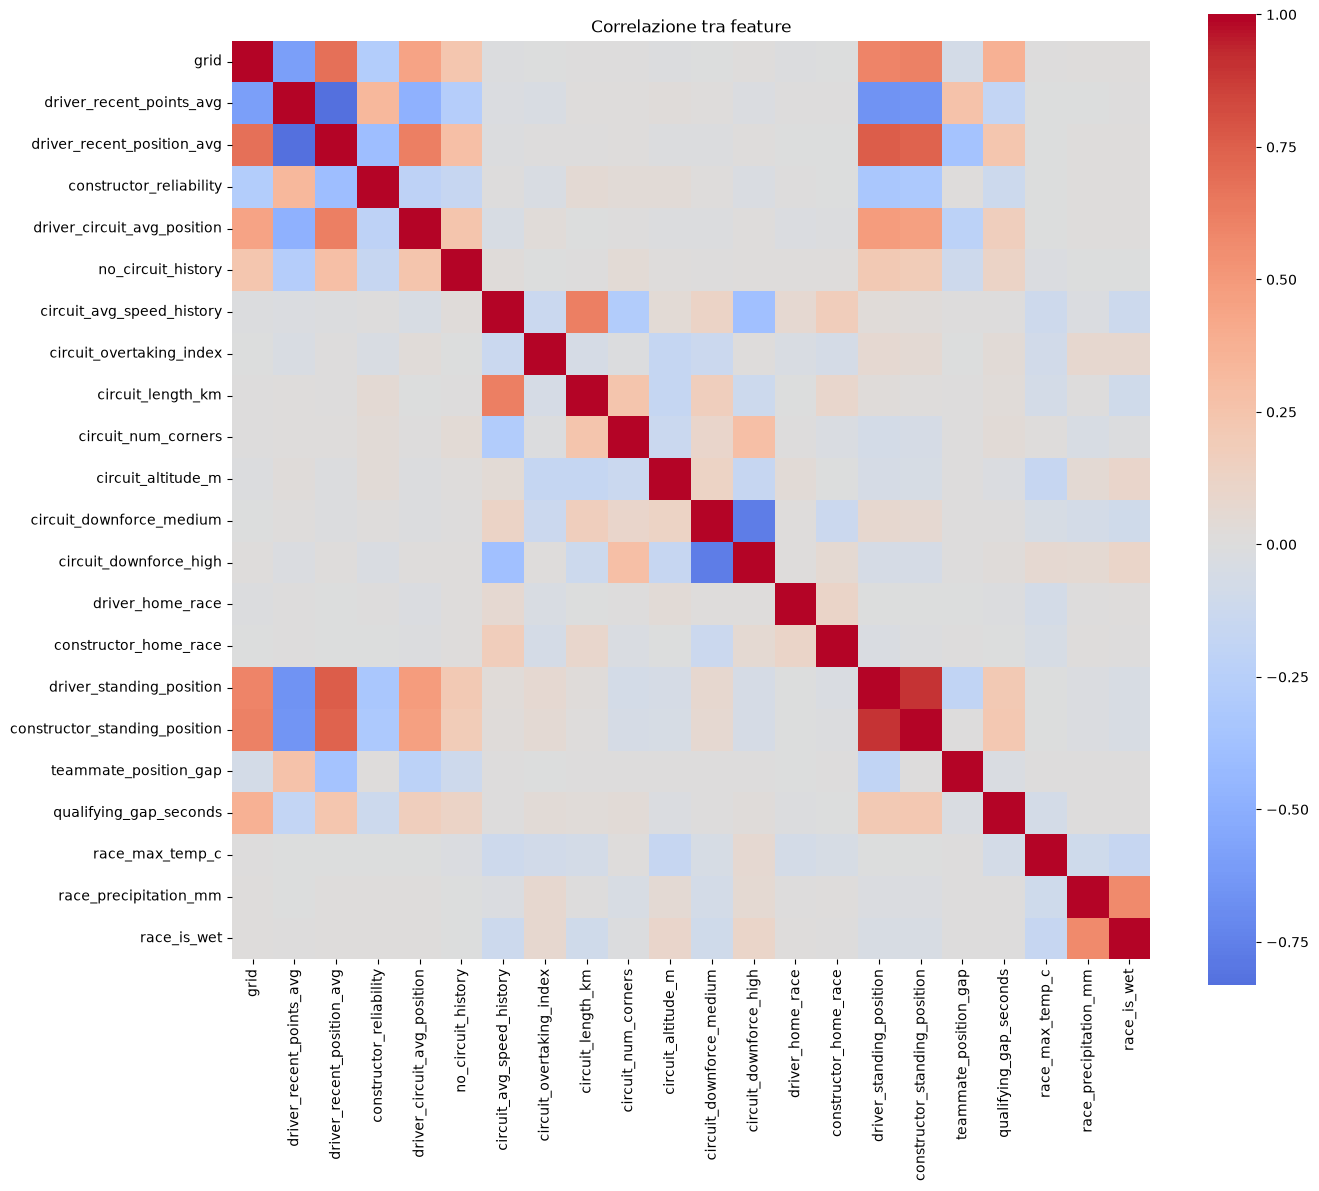

Coppie di feature molto correlate (>0.8):
constructor_standing_position  driver_standing_position    0.894330
driver_recent_position_avg     driver_recent_points_avg    0.832282
dtype: float64


In [43]:
corr_matrix = X_train.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlazione tra feature")
plt.tight_layout()
plt.show()

# Coppie con correlazione molto alta (>0.8): probabile ridondanza,
# una delle due potrebbe essere superflua
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.8)]
print("Coppie di feature molto correlate (>0.8):")
print(high_corr.drop_duplicates())

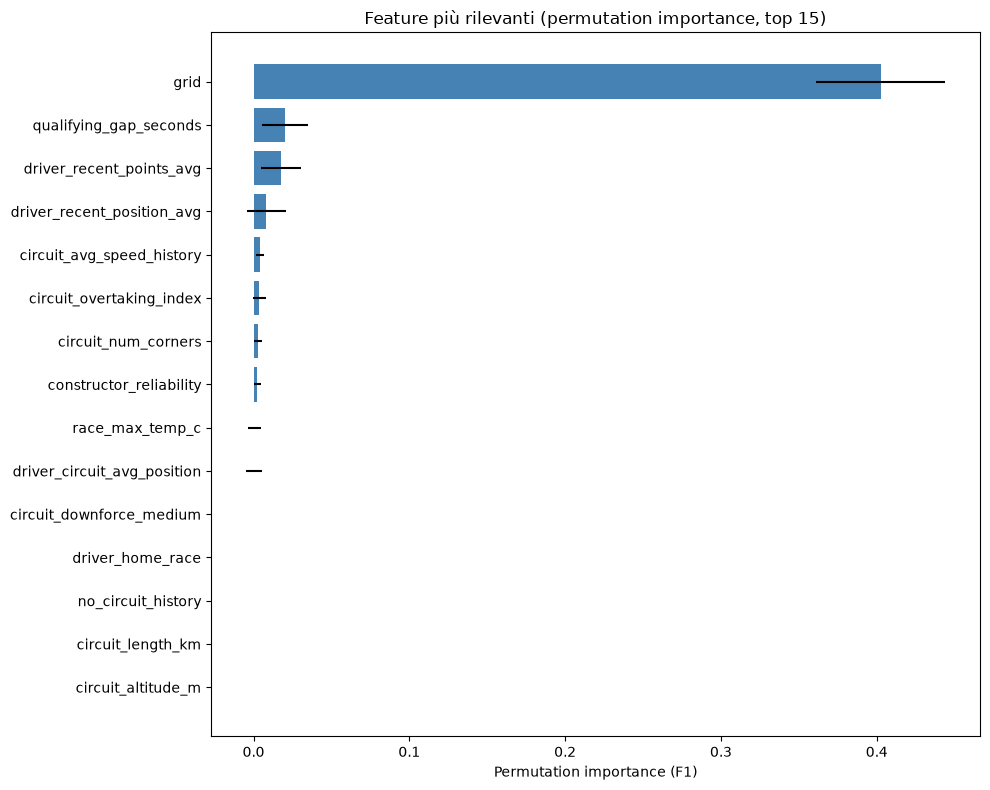

In [44]:
plt.figure(figsize=(10, 8))
top15 = perm_importance.head(15).sort_values("perm_importance_mean")
plt.barh(top15["feature"], top15["perm_importance_mean"],
         xerr=top15["perm_importance_std"], color="steelblue")
plt.xlabel("Permutation importance (F1)")
plt.title("Feature più rilevanti (permutation importance, top 15)")
plt.tight_layout()
plt.show()

In [45]:
# Quante righe hanno il valore di fallback invece di un gap realmente calcolato dai tempi?
fallback_value = df["qualifying_gap_seconds"].max()
n_fallback = (df["qualifying_gap_seconds"] == fallback_value).sum()
print(f"Righe con valore di fallback: {n_fallback} su {df.shape[0]} ({n_fallback/df.shape[0]*100:.1f}%)")

Righe con valore di fallback: 166 su 9278 (1.8%)


In [46]:
# 1. Il fallback è distribuito uniformemente nel tempo, o concentrato in specifici anni? 
# Un pattern concentrato spiegherebbe meglio il problema di un 9.6% sparso a caso
fallback_by_year = df.groupby("year").apply(
    lambda g: (g["qualifying_gap_seconds"] == df["qualifying_gap_seconds"].max()).mean() * 100
)
print("Percentuale di fallback per anno:")
print(fallback_by_year[fallback_by_year > 5])  # mostra solo gli anni sopra il 5%
print(df[df["year"].isin([2004, 2005])].shape[0], "righe nel 2004-2005")
print((df[df["year"].isin([2004, 2005])]["qualifying_gap_seconds"] == df["qualifying_gap_seconds"].max()).mean() * 100, "% di fallback in quei due anni")
# Confronto diretto: il gap medio in qualifica è più basso per chi fa podio? Se la differenza è marcata, la feature ha segnale reale
print(df.groupby("podium")["qualifying_gap_seconds"].mean())
print(df.groupby("podium")["qualifying_gap_seconds"].median())
# Chi ha il valore di fallback, fa podio più o meno spesso della media?
# Se il fallback corrisponde quasi sempre a "non podio" (es. piloti di fondo griglia con dati mancanti), il modello potrebbe imparare un pattern spurio invece del vero segnale del gap
fallback_mask = df["qualifying_gap_seconds"] == df["qualifying_gap_seconds"].max()
print("Tasso di podio tra le righe con fallback:", df[fallback_mask]["podium"].mean())
print("Tasso di podio tra le righe con dato reale:", df[~fallback_mask]["podium"].mean())

Percentuale di fallback per anno:
year
2004    5.373134
2025    5.882353
dtype: float64
701 righe nel 2004-2005
4.9928673323823105 % di fallback in quei due anni
podium
False    2.882218
True     0.759879
Name: qualifying_gap_seconds, dtype: float64
podium
False    1.6375
True     0.2795
Name: qualifying_gap_seconds, dtype: float64
Tasso di podio tra le righe con fallback: 0.060240963855421686
Tasso di podio tra le righe con dato reale: 0.14596136962247586


In [47]:
import shap

# TreeExplainer è ottimizzato specificamente per modelli ad albero (XGBoost, Random Forest)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Importanza media assoluta per feature: la magnitudine media dell'impatto che ciascuna feature ha avuto sulle previsioni nel test set
shap_importance = pd.DataFrame({
    "feature": FEATURE_COL,
    "shap_importance": np.abs(shap_values).mean(axis=0)
}).sort_values("shap_importance", ascending=False)

print(shap_importance.to_string(index=False))

                      feature  shap_importance
                         grid         1.021949
   driver_recent_position_avg         0.487519
       qualifying_gap_seconds         0.388707
     driver_recent_points_avg         0.209771
     driver_standing_position         0.200496
constructor_standing_position         0.084229
  driver_circuit_avg_position         0.026254
     circuit_overtaking_index         0.017687
        teammate_position_gap         0.014810
        race_precipitation_mm         0.008017
      constructor_reliability         0.007472
              race_max_temp_c         0.006648
    circuit_avg_speed_history         0.005811
          circuit_num_corners         0.003634
           circuit_altitude_m         0.002780
            circuit_length_km         0.002343
       circuit_downforce_high         0.000823
           no_circuit_history         0.000698
        constructor_home_race         0.000564
                  race_is_wet         0.000529
     circuit_

In [48]:
final_comparison = gain_importance.merge(perm_importance, on="feature").merge(shap_importance, on="feature")
final_comparison = final_comparison.sort_values("shap_importance", ascending=False)
print(final_comparison.to_string(index=False))

                      feature  gain_importance  perm_importance_mean  perm_importance_std  shap_importance
                         grid         0.343089              0.402502             0.041338         1.021949
   driver_recent_position_avg         0.128498              0.008192             0.012506         0.487519
       qualifying_gap_seconds         0.089305              0.020270             0.014890         0.388707
     driver_recent_points_avg         0.054124              0.017815             0.012848         0.209771
     driver_standing_position         0.113417              0.000000             0.000000         0.200496
constructor_standing_position         0.050727              0.000000             0.000000         0.084229
  driver_circuit_avg_position         0.020883              0.000206             0.005000         0.026254
     circuit_overtaking_index         0.018125              0.003818             0.004292         0.017687
        teammate_position_gap        

In [49]:
FEATURES_TO_DROP = [
    "circuit_altitude_m", "circuit_length_km", "circuit_downforce_high",
    "circuit_downforce_medium", "no_circuit_history", "constructor_home_race",
    "race_is_wet", "driver_home_race",
]
FEATURE_COL_TRIMMED = [f for f in FEATURE_COL if f not in FEATURES_TO_DROP]
print(f"Feature: {len(FEATURE_COL)} -> {len(FEATURE_COL_TRIMMED)}")

# Riusiamo train_champion_model così com'è, ma serve un DataFrame con
# solo le colonne ridotte + 'podium', dato che la funzione seleziona
# internamente FEATURE_COL (fisso) — costruiamo un sotto-DataFrame
# temporaneo per non modificare la funzione in src/train.py
train_df_trimmed = train_df[FEATURE_COL_TRIMMED + ["podium"]].copy()
test_df_trimmed = test_df[FEATURE_COL_TRIMMED + ["podium"]].copy()

# train_champion_model usa FEATURE_COL importato da src.train — per
# farla lavorare sul set ridotto senza toccare il file sorgente,
# replichiamo qui la stessa logica invece di richiamarla direttamente
from src.train import XGB_CHAMPION_PARAMS
from xgboost import XGBClassifier

X_train_trimmed = train_df_trimmed[FEATURE_COL_TRIMMED]
y_train_trimmed = train_df_trimmed["podium"]
scale_pos_weight = (y_train_trimmed == 0).sum() / (y_train_trimmed == 1).sum()

model_trimmed = XGBClassifier(scale_pos_weight=scale_pos_weight, **XGB_CHAMPION_PARAMS)
model_trimmed.fit(X_train_trimmed, y_train_trimmed)

# Stessa ricerca soglia ottimale usata ovunque nel progetto
def find_best_threshold_manual(model, X_test, y_test, thresholds=np.arange(0.1, 0.95, 0.05)):
    y_proba = model.predict_proba(X_test)[:, 1]
    best_f1, best = -1, None
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_test, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best = {"threshold": t, "precision": precision_score(y_test, y_pred),
                    "recall": recall_score(y_test, y_pred), "f1": f1}
    return best

from sklearn.metrics import precision_score, recall_score

X_test_trimmed = test_df_trimmed[FEATURE_COL_TRIMMED]
y_test_trimmed = test_df_trimmed["podium"]

best_trimmed = find_best_threshold_manual(model_trimmed, X_test_trimmed, y_test_trimmed)

print("\n=== Confronto: 22 feature (attuale) vs 14 feature (anteprima, stessi iperparametri) ===")
print(f"22 feature — soglia 0.65: precision 0.614, recall 0.847, F1 0.712")
print(f"14 feature — soglia {best_trimmed['threshold']:.2f}: "
      f"precision {best_trimmed['precision']:.3f}, recall {best_trimmed['recall']:.3f}, F1 {best_trimmed['f1']:.3f}")

Feature: 22 -> 14

=== Confronto: 22 feature (attuale) vs 14 feature (anteprima, stessi iperparametri) ===
22 feature — soglia 0.65: precision 0.614, recall 0.847, F1 0.712
14 feature — soglia 0.65: precision 0.608, recall 0.838, F1 0.705


## Prima di eliminare le features poco influenti, mi assicuro che fossero implementate bene

In [52]:
FEATURES_TO_DROP = [
    "circuit_altitude_m", "circuit_length_km", "circuit_downforce_high",
    "circuit_downforce_medium", "no_circuit_history", "constructor_home_race",
    "race_is_wet", "driver_home_race",
]

print("=== 1. Distribuzione dei valori (non deve essere costante/quasi-costante) ===\n")
for f in FEATURES_TO_DROP:
    n_unique = df[f].nunique()
    print(f"{f}: {n_unique} valori unici, distribuzione:")
    print(df[f].value_counts(normalize=True).head(5))
    print()

print("=== 2. Legame con il target, feature per feature ===\n")
for f in FEATURES_TO_DROP:
    if df[f].nunique() <= 5:
        # Feature categoriche/binarie: confronta tasso di podio per categoria
        print(f"{f} — tasso di podio per valore:")
        print(df.groupby(f)["podium"].mean())
    else:
        # Feature continue: confronta media per chi fa podio vs no
        print(f"{f} — media per podio True/False:")
        print(df.groupby("podium")[f].mean())
    print()

print("=== 3. Casi specifici da verificare a mano ===\n")

# Gara di casa: controlla un caso noto (Verstappen a Zandvoort)
verstappen_zandvoort = df.merge(data["drivers"][["driverId","surname"]], on="driverId")
check = verstappen_zandvoort[
    (verstappen_zandvoort["surname"] == "Verstappen") &
    (verstappen_zandvoort["circuitId"] == data["circuits"][data["circuits"]["circuitRef"]=="zandvoort"]["circuitId"].iloc[0])
]
print("Verstappen a Zandvoort, driver_home_race:", check["driver_home_race"].unique())

# Meteo: verifica che le gare storicamente note come piovose abbiano race_is_wet=1
# (es. GP Germania 2019, GP Turchia 2020 sono famosi per pioggia)
wet_check = df.merge(data["races"][["raceId","name"]], on="raceId")
print("\nGare con precipitazioni più alte (dovrebbero essere gare famose per pioggia):")
print(wet_check.nlargest(5, "race_precipitation_mm")[["name","year","race_precipitation_mm","race_is_wet"]])

for ref in ["monaco", "spa", "monza"]:
    cid = data["circuits"][data["circuits"]["circuitRef"]==ref]["circuitId"].iloc[0]
    length = df[df["circuitId"]==cid]["circuit_length_km"].iloc[0]
    print(f"{ref}: circuit_length_km = {length}")


print("driver_recent_position_avg per no_circuit_history:")
print(df.groupby("no_circuit_history")["driver_recent_position_avg"].mean())
print("\ndriver_standing_position per no_circuit_history:")
print(df.groupby("no_circuit_history")["driver_standing_position"].mean())

=== 1. Distribuzione dei valori (non deve essere costante/quasi-costante) ===

circuit_altitude_m: 35 valori unici, distribuzione:
circuit_altitude_m
7      0.096249
18     0.068657
153    0.054214
109    0.052059
264    0.051843
Name: proportion, dtype: float64

circuit_length_km: 36 valori unici, distribuzione:
circuit_length_km
5.412    0.057448
5.891    0.054214
4.657    0.052059
4.381    0.051843
5.793    0.051843
Name: proportion, dtype: float64

circuit_downforce_high: 2 valori unici, distribuzione:
circuit_downforce_high
0    0.628907
1    0.371093
Name: proportion, dtype: float64

circuit_downforce_medium: 2 valori unici, distribuzione:
circuit_downforce_medium
0    0.50776
1    0.49224
Name: proportion, dtype: float64

no_circuit_history: 2 valori unici, distribuzione:
no_circuit_history
0    0.754473
1    0.245527
Name: proportion, dtype: float64

constructor_home_race: 2 valori unici, distribuzione:
constructor_home_race
0    0.954624
1    0.045376
Name: proportion, dtype: 

## Retuning sulle 14 features

In [53]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

xgb_param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 1.5, 2],
}

search_trimmed = RandomizedSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss", n_jobs=1),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_trimmed.fit(X_train_trimmed, y_train_trimmed)

print("Migliori parametri (14 feature):")
print(search_trimmed.best_params_)
print(f"Miglior average_precision in CV: {search_trimmed.best_score_:.4f}")

best_tuned_trimmed = find_best_threshold_manual(search_trimmed.best_estimator_, X_test_trimmed, y_test_trimmed)
print(f"\nRisultato finale — soglia {best_tuned_trimmed['threshold']:.2f}: "
      f"precision {best_tuned_trimmed['precision']:.3f}, recall {best_tuned_trimmed['recall']:.3f}, F1 {best_tuned_trimmed['f1']:.3f}")

print(f"\nConfronto:")
print(f"22 feature, tunato in precedenza — soglia 0.65: precision 0.614, recall 0.847, F1 0.712")
print(f"14 feature, appena tunato — soglia {best_tuned_trimmed['threshold']:.2f}: "
      f"precision {best_tuned_trimmed['precision']:.3f}, recall {best_tuned_trimmed['recall']:.3f}, F1 {best_tuned_trimmed['f1']:.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Migliori parametri (14 feature):
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Miglior average_precision in CV: 0.6877

Risultato finale — soglia 0.70: precision 0.640, recall 0.802, F1 0.712

Confronto:
22 feature, tunato in precedenza — soglia 0.65: precision 0.614, recall 0.847, F1 0.712
14 feature, appena tunato — soglia 0.70: precision 0.640, recall 0.802, F1 0.712
